## 1. Download the Dataset

In [ ]:
# SKIP if data is already at data/hockeyai
from huggingface_hub import hf_hub_download
import zipfile
import os

zip_path = hf_hub_download(
    repo_id="SimulaMet-HOST/HockeyAI",
    repo_type="dataset",
    filename="HockeyAI_Dataset.zip",
    local_dir="./hockeyai"
)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("./hockeyai")

print("Download and extraction complete.")

HockeyAI_Dataset.zip:   0%|          | 0.00/404M [00:00<?, ?B/s]

Download and extraction complete.


## 2. Verify File Structure

In [5]:
import glob
from pathlib import Path

FRAMES_DIR = "../data/hockeyai/SHL/frames"
ANNOTS_DIR = "../data/hockeyai/SHL/annotations"

img_files = glob.glob(os.path.join(FRAMES_DIR, "*.jpg"))
ann_files = glob.glob(os.path.join(ANNOTS_DIR, "*.txt"))

print(f"Image files:      {len(img_files)}")
print(f"Annotation files: {len(ann_files)}")

sample_ann = ann_files[0]
print(f"\nSample annotation ({Path(sample_ann).name}):")
with open(sample_ann) as f:
    for line in f:
        print(" ", line.strip())

Image files:      2101
Annotation files: 2101

Sample annotation (45dae0d8-63c1-4c1b-a5f7-136142fe3bdf.txt):
  5 0.810882800608828 0.5412719891745602 0.0144596651445967 0.013531799729364025
  6 0.21552579365079366 0.41490299823633153 0.03224206349206348 0.10141093474426803
  4 0.1909722222222222 0.5026455026455027 0.07242063492063493 0.10052910052910051
  4 0.269593253968254 0.6199294532627866 0.05902777777777775 0.1534391534391534
  4 0.4174107142857143 0.6005291005291006 0.05307539682539677 0.14109347442680772
  4 0.6001984126984127 0.6040564373897707 0.06150793650793652 0.22222222222222215
  4 0.37996031746031744 0.7261904761904762 0.11111111111111115 0.1613756613756614
  4 0.10143849206349205 0.8827160493827162 0.09970238095238095 0.2328042328042328
  3 0.09920634920634921 0.754409171075837 0.19841269841269843 0.2495590828924163
  1 0.6830357142857143 0.47354497354497355 0.31150793650793646 0.10052910052910058
  1 0.9169146825396816 0.6816578483245149 0.16617063492063436 0.20634920

## 3. Parse Annotations

In [6]:
from collections import Counter, defaultdict
import numpy as np

CLASS_NAMES = {
    0: "Center Ice",
    1: "Faceoff Dots",
    2: "Goal Frame",
    3: "Goaltender",
    4: "Players",
    5: "Puck",
    6: "Referee"
}

class_counts    = Counter()
bbox_areas      = defaultdict(list)
boxes_per_image = []
images_without_puck = 0

for ann_path in ann_files:
    with open(ann_path) as f:
        lines = [l.strip() for l in f if l.strip()]

    boxes_per_image.append(len(lines))
    class_ids_this_img = set()

    for line in lines:
        parts = line.split()
        cls = int(parts[0])
        cx, cy, w, h = map(float, parts[1:5])
        class_counts[cls] += 1
        class_ids_this_img.add(cls)
        bbox_areas[cls].append(w * h)  # normalized area

    if 5 not in class_ids_this_img:
        images_without_puck += 1

print("Class distribution (total boxes):")
print(f"{'Class':<15} {'Count':>6}  {'Avg BBox Area':>14}")
print("-" * 40)
for cls_id, name in CLASS_NAMES.items():
    count    = class_counts[cls_id]
    avg_area = np.mean(bbox_areas[cls_id]) * 100 if bbox_areas[cls_id] else 0
    print(f"{name:<15} {count:>6}  {avg_area:>13.2f}%")

print(f"\nBoxes per image — Min: {min(boxes_per_image)}, Max: {max(boxes_per_image)}, "
      f"Mean: {np.mean(boxes_per_image):.1f}, Median: {np.median(boxes_per_image):.1f}")
print(f"Images missing puck annotation: {images_without_puck} / {len(ann_files)}")

Class distribution (total boxes):
Class            Count   Avg BBox Area
----------------------------------------
Center Ice         591           8.81%
Faceoff Dots      3460           8.61%
Goal Frame        1219           2.80%
Goaltender        1281           1.24%
Players          13660           1.41%
Puck              2103           0.03%
Referee           1948           0.75%

Boxes per image — Min: 1, Max: 23, Mean: 11.5, Median: 12.0
Images missing puck annotation: 0 / 2101


## 4. Image Resolutions

In [ ]:
from PIL import Image

resolutions = Counter()
for p in img_files[:200]:
    w, h = Image.open(p).size
    resolutions[(w, h)] += 1

print("Image resolutions (sampled 200):")
for res, count in resolutions.most_common():
    print(f"  {res[0]}x{res[1]}: {count} images")

Image resolutions (sampled 200):
  1920x1080: 200 images


## 5. Visualize

/var/folders/4f/_9hp2ljs1_9b115tgxwpth380000gn/T/ipykernel_40118/688524062.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(names, rotation=30, ha="right")


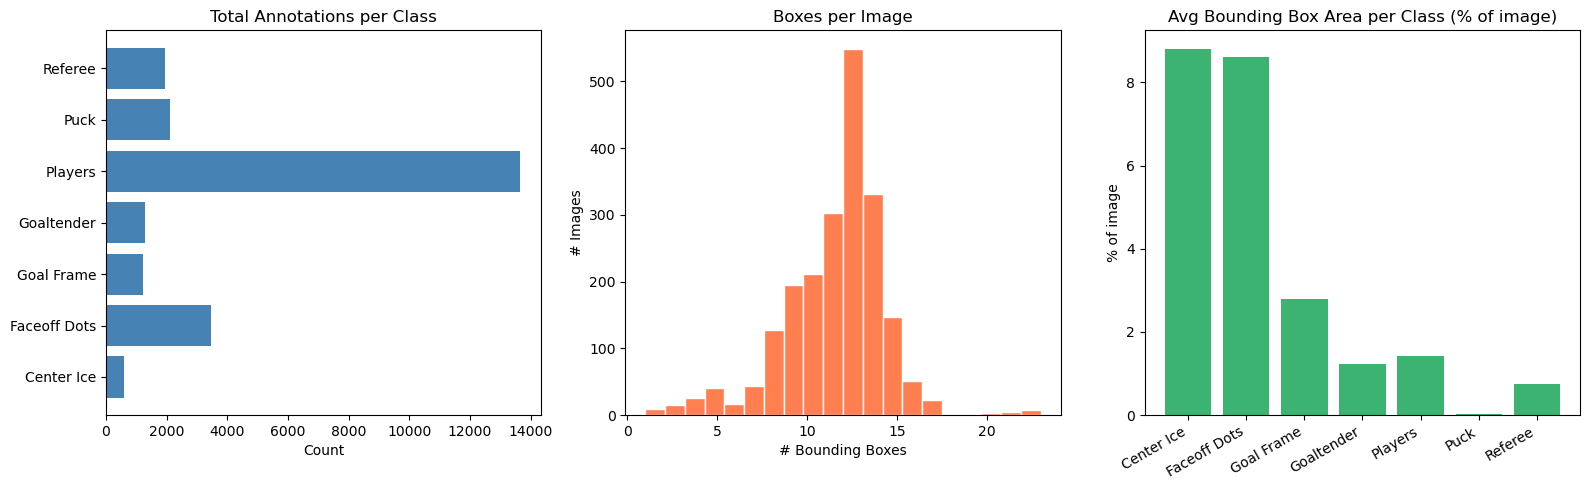

Saved: hockeyai_eda.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class distribution
names  = [CLASS_NAMES[i] for i in sorted(class_counts)]
counts = [class_counts[i] for i in sorted(class_counts)]
axes[0].barh(names, counts, color="steelblue")
axes[0].set_title("Total Annotations per Class")
axes[0].set_xlabel("Count")

# Boxes per image
axes[1].hist(boxes_per_image, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Boxes per Image")
axes[1].set_xlabel("# Bounding Boxes")
axes[1].set_ylabel("# Images")

# Avg bbox area per class
avg_areas = [np.mean(bbox_areas[i]) * 100 for i in sorted(bbox_areas)]
axes[2].bar(names, avg_areas, color="mediumseagreen")
axes[2].set_title("Avg Bounding Box Area per Class (% of image)")
axes[2].set_xticklabels(names, rotation=30, ha="right")
axes[2].set_ylabel("% of image")

plt.tight_layout()
plt.savefig("hockeyai_eda.png", dpi=150)
plt.show()
print("Saved: hockeyai_eda.png")